In [2]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense,Flatten
from keras.models import Sequential
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from keras.datasets import mnist

In [3]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()


In [4]:
print("X_train shape: ",x_train.shape)
print("X_test shape: ",x_test.shape)
print("Y_train shape: ",y_train.shape)
print("Y_test shape: ",y_test.shape)

X_train shape:  (60000, 28, 28)
X_test shape:  (10000, 28, 28)
Y_train shape:  (60000,)
Y_test shape:  (10000,)


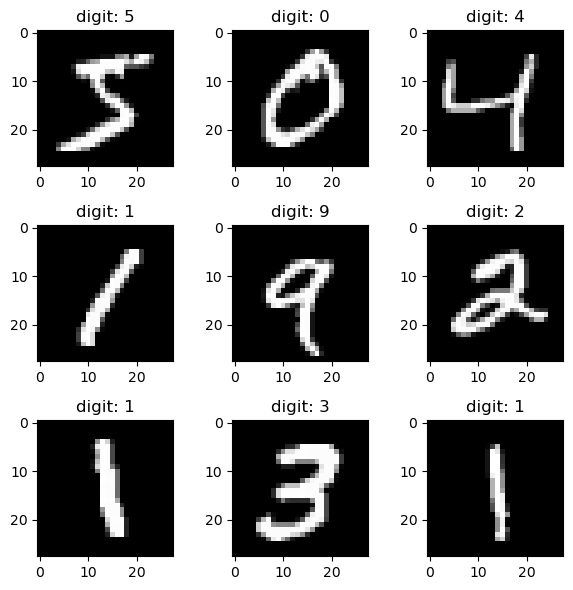

In [5]:
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i],cmap = "gray")
    plt.title(f"digit: {y_train[i]}")
    
plt.tight_layout()
# plt.title('off')
plt.show()
    

In [6]:
#normalization of data sets
new_x_train = x_train/256.0
new_x_test = x_test/256.0

In [7]:
model = Sequential()

In [8]:
model.add(Flatten(input_shape = (28,28)))
model.add(Dense(128,activation="tanh"))
model.add(Dense(64,activation="tanh"))
model.add(Dense(32,activation="tanh"))
model.add(Dense(10,activation="softmax"))

C:\Users\fahadch\anaconda4\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss = "sparse_categorical_crossentropy",optimizer = "adam")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.9151 - val_loss: 0.4747
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.6295 - val_loss: 1.1351
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.6454 - val_loss: 0.5253
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.6295 - val_loss: 0.6417
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.6292 - val_loss: 0.6729
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 1.6948 - val_loss: 1.8556
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 1.7826 - val_loss: 1.7346
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 2.1067 - val_loss: 2.3037
Epoch 9/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 2.3050 - val_loss: 2.3046
Epoch 10/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 2.3050 - val_loss: 2.3066
Epoch 11/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 2.3053 - val_loss: 2.3100
Epoch 12/20
1500/15

In [11]:
data={}
for i in range(5,11):
    his = model.fit(new_x_train,y_train,epochs=i,validation_split = 0.2)
    pred = model.predict(new_x_test)
    y_pred = pred.argmax(axis = 1)
    acc = accuracy_score(y_test,y_pred)
    data[i] = acc


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.3027 - val_loss: 0.1669
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.1321 - val_loss: 0.1443
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0913 - val_loss: 0.1125
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0662 - val_loss: 0.1071
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0548 - val_loss: 0.0949
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Epoch 1/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0428 - val_loss: 0.1108
Epoch 2/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0363 - val_loss: 0.1103
Epoch 3/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0281 - val_loss: 0.1021
Epoch 4/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0279 - val_loss: 0.1188
Epoch 5/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0194 - val_loss: 0.1140
Epoch 6/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0207 - val_loss: 0.1054

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [62]:
print("accuracy score: ",acc)

accuracy score:  0.9759


C:\Users\fahadch\AppData\Local\Temp\ipykernel_5616\4056522424.py:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "go--" (-> color='g'). The keyword argument will take precedence.
  plt.plot(his.history["loss"],"go--",color="blue")


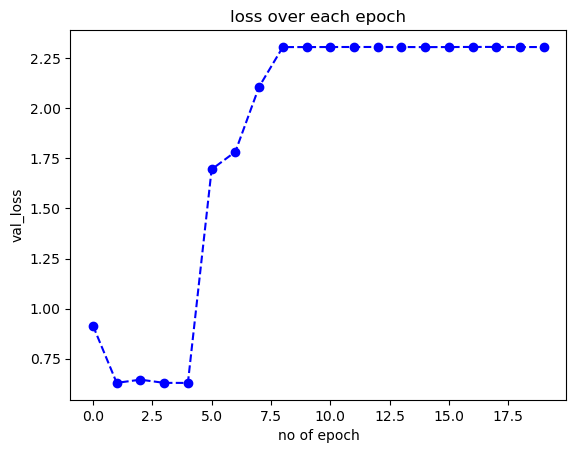

In [63]:
plt.plot(his.history["loss"],"go--",color="blue")
plt.title("loss over each epoch")
plt.xlabel("no of epoch")
plt.ylabel("val_loss")
plt.show()

C:\Users\fahadch\AppData\Local\Temp\ipykernel_5616\2269360774.py:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "go--" (-> color='g'). The keyword argument will take precedence.
  plt.plot(his.history["val_loss"],"go--",color="green")


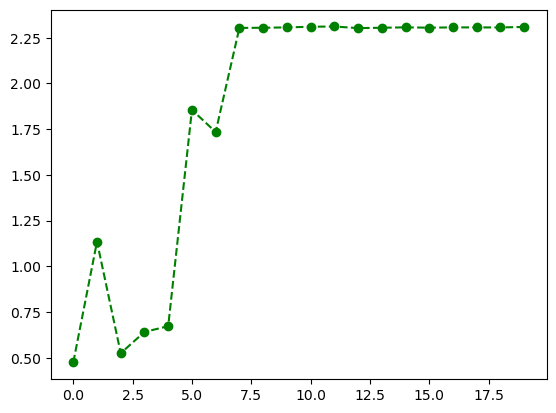

In [64]:
plt.plot(his.history["val_loss"],"go--",color="green")

In [50]:
# plt.subplot(1,2,1)
# plt.plot(his.history["loss"],"go--",color="blue")
# plt.title("loss over each epoch")
# plt.xlabel("no of epoch")
# plt.ylabel("val_loss")
# plt.show()
# plt.subplot(1,2,2)
# plt.plot(his.history["val_loss"],"go--",color="green")
# plt.title("loss over each epoch")
# plt.xlabel("no of epoch")
# plt.ylabel("val_loss")
# plt.show()

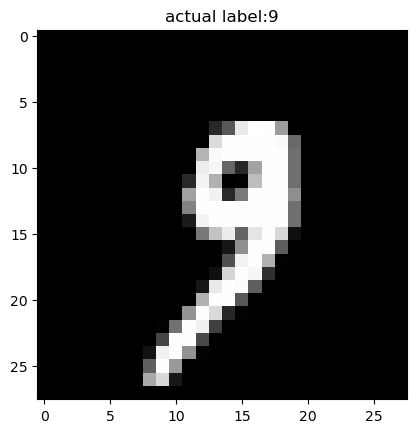

In [12]:
idx=1000
plt.imshow(x_test[idx],cmap='gray')
plt.title(f"actual label:{y_test[idx]}")
plt.show()

In [13]:
import numpy as np
sample=x_test[idx].reshape(1,28,28)
prediction=model.predict(sample)
predicted_class=np.argmax(prediction)
print("predicted:",predicted_class)
print("confidence:",prediction[0][predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
predicted: 9
confidence: 0.99999964


In [1]:
!git init

'git' is not recognized as an internal or external command,
operable program or batch file.
